# Forward diffusion process

SigmaDock uses **SE(3) diffusion**: translations follow a **VP-SDE** ($R^3$) and rotations an **IGSO(3)** (VE-style) process. This notebook visualizes the **forward** process: how clean poses ($T_0$, $R_0$) are noised to ($T_t$, $R_t$) at time t $\in$ [0, 1].

**You will:**
- Inspect noise schedules $\sigma(t)$ for SO(3) and $\alpha(t)$ for $R^3$
- Sample from the forward marginal at several times t
- See how pose uncertainty grows with t

In [1]:
import os
from pathlib import Path

DATA_DIR = Path(os.environ.get("SIGMADOCK_DATA_DIR", "../data")).resolve()
if not DATA_DIR.exists():
    raise SystemExit(f"Please set SIGMADOCK_DATA_DIR or create {DATA_DIR}!")
CKPT_PATH = Path(os.environ.get("SIGMADOCK_CKPT_DIR", "../checkpoints/sample_checkpoint_0.ckpt")).resolve()

import matplotlib.pyplot as plt
import torch

try:
    torch.set_float32_matmul_precision('high')
except:
    print("[WARN] torch.set_float32_matmul_precision not available for this GPU. Using default precision.")

from sigmadock.diff.r3_diffuser import R3Diffuser
from sigmadock.diff.se3_diffuser import SE3Diffuser
from sigmadock.diff.so3_diffuser import SO3Diffuser

# Use a small cache dir (e.g. under project or /tmp); 
CACHE = Path(".cache_igso3")
CACHE.mkdir(exist_ok=True)

## 1. Noise schedules

**$R^3$ (translations):** VP-SDE with $\beta(t)$ = $\min_\beta$ + t($\max_\beta$ − $\min_\beta$). The marginal is $p(x_t|x_0)$ with $\alpha(t) = \exp\left(−\int\beta/2\right); \sigma(t) = \sqrt{(1 − \alpha(t)^2)}$.

**SO(3) (rotations):** VE-style with logarithmic $\sigma(t)$; IGSO(3) density is used for sampling and score.

Using cached IGSO3 in .cache_igso3/eps_1000_omega_2000_min_sigma_0_1_max_sigma_1_5_schedule_logarithmic


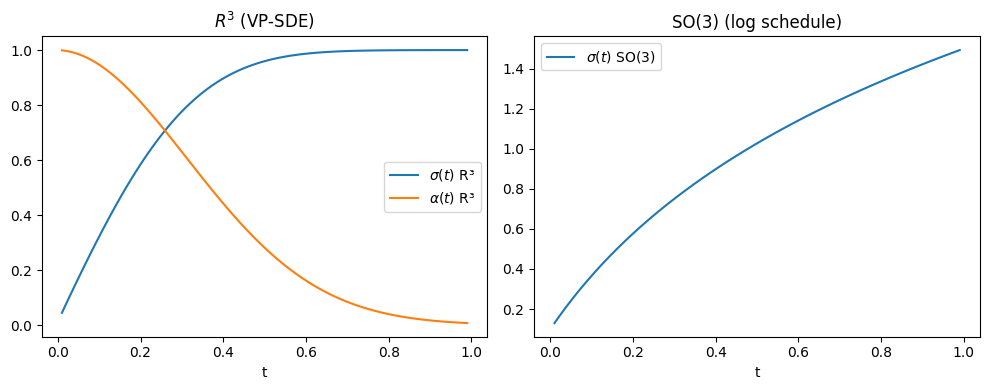

In [2]:
# First run may compute IGSO3 tables cached into CACHE. Expect this to take a few minutes.
r3 = R3Diffuser(min_beta=0.1, max_beta=20.0)
so3 = SO3Diffuser(
    cache_path=CACHE,
    use_cached_score=True,
)

t = torch.linspace(0.01, 0.99, 100)
sigma_r3 = r3.sigma(t)
sigma_so3 = so3.sigma(t)
alpha_r3 = torch.exp(-r3.integrated_beta_t(t) / 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(t.numpy(), sigma_r3.numpy(), label=r"$\sigma(t)$ R³")
axes[0].plot(t.numpy(), alpha_r3.numpy(), label=r"$\alpha(t)$ R³")
axes[0].set_xlabel("t")
axes[0].legend()
axes[0].set_title("$R^3$ (VP-SDE)")
axes[1].plot(t.numpy(), sigma_so3.numpy(), label=r"$\sigma(t)$ SO(3)")
axes[1].set_xlabel("t")
axes[1].legend()
axes[1].set_title("SO(3) (log schedule)")
plt.tight_layout()
plt.show()

## 2. Forward marginal sampling

Given initial translation T₀ and rotation R₀, we sample (T_t, R_t) ~ p(·|T₀, R₀, t) using `SE3Diffuser.forward_marginal`.

In [3]:
se3 = SE3Diffuser(
    min_beta=0.1,
    max_beta=20.0,
    schedule="logarithmic",
    min_sigma=0.1,
    max_sigma=1.5,
    num_sigma=1000,
    num_omega=2000,
    cache_path=CACHE,
    use_cached_score=True,
)

n = 64
T_0 = torch.randn(n, 3) * 4.0
R_0 = torch.eye(3).unsqueeze(0).expand(n, 3, 3)

for t_val in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]:
    t_batch = torch.full((n,), t_val)
    out = se3.forward_marginal(T_0, R_0, t_batch)
    T_t, R_t = out["T_t"], out["R_t"]
    print(f"t={t_val:.1f}: T_t norm mean = {T_t.norm(dim=1).mean():.3f}, R_t shape = {R_t.shape}")

Using cached IGSO3 in .cache_igso3/eps_1000_omega_2000_min_sigma_0_1_max_sigma_1_5_schedule_logarithmic
t=0.1: T_t norm mean = 5.966, R_t shape = torch.Size([64, 3, 3])
t=0.2: T_t norm mean = 5.251, R_t shape = torch.Size([64, 3, 3])
t=0.4: T_t norm mean = 3.180, R_t shape = torch.Size([64, 3, 3])
t=0.6: T_t norm mean = 1.824, R_t shape = torch.Size([64, 3, 3])
t=0.8: T_t norm mean = 1.555, R_t shape = torch.Size([64, 3, 3])
t=1.0: T_t norm mean = 1.498, R_t shape = torch.Size([64, 3, 3])


## 3. Summary

- **$R^3$**: VP-SDE; forward is $x_t = \alpha(t)x_0 + \sqrt{(1−\alpha(t)^2)}\epsilon$.
- **SO(3)**: IGSO(3) forward marginal; $\sigma(t)$ grows with t (log schedule).
- Training learns the score; sampling runs the reverse SDE from t=1 to t≈0 using the learned score.

In [28]:
import copy
from pathlib import Path

from sigmadock.chem.fragmentation import get_fragments_as_mols
from sigmadock.config import get_experiment_config
from sigmadock.data import SigmaDataset
from sigmadock.datafronts import MetaFront
from sigmadock.chem.pyviz import view_pocket_fragments

config = get_experiment_config("posebusters", DATA_DIR)
datafront = MetaFront([config])
if config.name == "posebusters":
    try:
        # Prune out data from blacklist (PoseBusters paper).
        def load_pdbs_from_txt(txt_path: Path) -> list[str]:
            """Load PDB IDs from a text file."""
            with open(txt_path) as f:
                pdb_ids = [line.strip() for line in f if line.strip()]
            return pdb_ids
        selected_ids = load_pdbs_from_txt(
            DATA_DIR / "posebusters_paper/posebusters_pdb_ccd_ids.txt",
        )
        datafront.prune_pairs_with_ids(selected_ids)
    except Exception as e:
        print(f"[WARN] Error loading posebusters_pdb_ccd_ids.txt: {e}, continuing with all data.")
        print("Please get the correct ids from the newer PoseBusters release / github and place them in the data directory for correct comparison.")

dataset = SigmaDataset(
    datafront=datafront,
    use_esm_embeddings=False,
    # Using bound ligand conformer for testing & simple visualization.
    sample_conformer=False,
    alignment_tries=0,
    skip_bounds_check=True,
    pocket_distance_cutoff=6.0,
    pocket_com_noise=0.5,
    pocket_distance_noise=0.5,
    seed=123,
    get_mol_info=True,
)
# Define a random index for testing
idx = 1
data = dataset[idx]
pocket_mol = copy.deepcopy(data.mol_info["pocket"])
original = copy.deepcopy(data.mol_info["original"])
frag_mol = data.mol_info["fragmented"]
frag_mol_list = get_fragments_as_mols(frag_mol)
display(
    view_pocket_fragments(
        pocket_mol,
        frag_mol_list,
        reference_ligand=None,
        pocket_style="stick",
        fragment_style="stick",
        fragment_opacity=0.5,
        width=600,
        height=500,
    )
)

INFO:posebusters.posebusters:Using default configuration for mode redock_fast.


Pruned pairs to 308/428 using provided IDs.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
from torch_geometric.data import Batch

from sigmadock.chem.statistics import get_mol_from_coords
from sigmadock.diff.sampling import sample_notebook
from sigmadock import HPARAMS
from sigmadock.utils import load_from_scratch
from sigmadock.diff.denoiser import SigmaDockDenoiser
from torch import nn

# NOTE: use USE_TRUE_SCORE=True if you just want to visualize forward-backward diffusion path.
USE_TRUE_SCORE=False
if CKPT_PATH.exists():
    model = load_from_scratch(
        CKPT_PATH,
        enforced_cfg={"cache_path": str(CACHE)},
        load_ema=True,
        strict=True,
    )
    denoiser = model.ema_model.model
    USE_TRUE_SCORE=False
else:
    print(f"[WARN] Checkpoint not found at {CKPT_PATH}. Using dummy model and true score for visualization.")
    class DummyModel(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.model = nn.Embedding(1,10)
            
        def forward(self, x):  # noqa: ANN201
            return self.model(x)

    model = DummyModel()
    denoiser = SigmaDockDenoiser(
        model=model,
        include_interactions=False,
        cache_path=CACHE,
    )
    USE_TRUE_SCORE=True

denoiser.eval()
denoiser.to("cuda")
device = next(denoiser.parameters()).device
denoiser.diffuser._so3_diffuser.set_device(device)

Error loading checkpoint with torch.load: No module named 'alphadock'. Attempting load with legacy module alias.
[WARNING] Using provided HPARAMS that could be modified from oracle.py
[WARN] Ignored kwargs in EquiformerV2: {'cache_path': '.cache_igso3'}. Please check for typos unless unintended.
[INFO] DIST | Skipping inter_fragments edges as ligand_ligand_interactions is False
Using cached IGSO3 in .cache_igso3/eps_1000_omega_2000_min_sigma_0_1_max_sigma_1_5_schedule_logarithmic
Successfully loaded EMA model.


In [9]:
batch = Batch.from_data_list([data])
batch, all_pos, all_edges, all_losses = sample_notebook(
    denoiser,
    batch,
    num_steps=25,
    rho=3,
    t_min=2e-3,
    t_max=0.99,
    noise_scale=0,
    verbose=True,
    use_true_scores=USE_TRUE_SCORE,
    seed=123,
)
print("Sampling complete.")
batch.to("cpu")
is_lig = (batch.frag_idx_map != -1) & (batch.node_entity <= 2)
com = batch.pocket_com[0].numpy()
lig_traj = [p[is_lig] * HPARAMS.general.dimensional_scale + com for p in all_pos]
sample_frag_mol = copy.deepcopy(data.mol_info["fragmented"])
frames = [
    get_fragments_as_mols(get_mol_from_coords(pos, sample_frag_mol))
    for pos in lig_traj
]
# NOTE you can select the subset of frames to view, i.e. every 5 steps. If < 1, view the last frame.
view_every: int = 0
view_pocket_fragments(
    copy.deepcopy(data.mol_info["pocket"]),
    frames[::view_every] if view_every > 1 else frames[-1],
    reference_ligand=copy.deepcopy(data.mol_info["original"]),
    fragment_opacity=1.0,
    pocket_style="stick",
    fragment_style="stick",
    pocket_surface_opacity=0.4,
    ref_ligand_opacity=0.6,
    pocket_alpha=0.4,
    reference_color="green",
    pocket_surface_color="gray",
    pocket_surface=False,
    width=600,
    height=500,
    view_dummies=False,
)

# NOTE: Some fragment dummy atoms might not overlap but that is intended - these are actually over-constrained dummy atoms left for visualsation.
# NOTE: This shows the overconstrained dummy atoms in the original conformer are employed.
# NOTE: If visualizer is buggy and blank, slide the "frame window" to revive.

[WARN] Moving batch to model device.
Using 25 steps for reverse sampling with: 
             seed=123 
             rho=3 
             solver=euler 
             noise_scale=0 
             t_min=0.002 
             


0it [00:00, ?it/s]

24it [00:02,  8.53it/s]

Sampling complete.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. Batch sampling (multi-seed), PoseBusters, and heuristics

In practice we run **multiple seeds** per complex, then evaluate with **PoseBusters** (e.g. sRMSD ≤ 2 Å, stereochemistry, clashes) and **top-k heuristics** (success rate and mean min RMSD vs k). Below we run a short multi-seed loop, then the full pipeline: PoseBusters on each pose, postprocessing checks, heuristic ranking, and top-k / delta-k figures. For larger batches and Vina-based ranking see **extensions/sampling.ipynb** and **examples/statistics.ipynb**.

In [10]:
from copy import deepcopy
import numpy as np
from pytorch_lightning import seed_everything
from tqdm import tqdm
from torch_geometric.data import DataLoader

# Get Batch object
BATCH_SIZE = 64

seed_everything(0, workers=True, verbose=False)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
for batch in loader:
    batch = batch.to(next(denoiser.parameters()).device)
    print(f"Collected {batch.num_graphs} graphs.")
    break

# Use a fresh batch for each seed (same data as in the trajectory cell above)
num_seeds = 10
seeds = np.random.randint(0, 1000, size=num_seeds).tolist()
all_outputs = []
for i, seed in enumerate(seeds):
    out = sample_notebook(
        denoiser=denoiser,
        batch=deepcopy(batch),
        num_steps=25,
        rho=3,
        t_min=2e-3,
        t_max=0.99,
        discretization="edm",
        solver="euler",
        noise_scale=0,
        noise_decay=1,
        seed=seed,
        use_true_scores=USE_TRUE_SCORE,
        verbose=(i == 0),
    )
    all_outputs.append(out)
print(f"Ran {num_seeds} seeds; {len(all_outputs)} outputs. Run the cell below for PoseBusters + heuristics.")

Collected 64 graphs.
Using 25 steps for reverse sampling with: 
             seed=879 
             rho=3 
             solver=euler 
             noise_scale=0 
             t_min=0.002 
             


24it [00:20,  1.19it/s]
24it [00:19,  1.21it/s]
24it [00:20,  1.19it/s]
24it [00:20,  1.17it/s]
24it [00:20,  1.19it/s]
24it [00:20,  1.20it/s]
24it [00:19,  1.20it/s]
24it [00:20,  1.19it/s]
24it [00:20,  1.19it/s]
24it [00:20,  1.19it/s]

Ran 10 seeds; 10 outputs. Run the cell below for PoseBusters + heuristics.


### Visualize Sample From Batch

In [26]:
import ipywidgets as widgets
import plotly.graph_objs as go
from IPython.display import display

from sigmadock.geo.viz import plot_interaction_graph_3d_plotly
from sigmadock.torch_utils.utils import re_batch_with_attrs

STEP = -1
BATCH_IDX = 25
SEED_IDX = 0
# Index of the seed to evaluate

sample_batch, sample_pos, sample_edges = all_outputs[SEED_IDX][0], all_outputs[SEED_IDX][1], all_outputs[SEED_IDX][2]
sample_batch.pos_t = torch.Tensor(sample_pos[STEP])
batch_out = re_batch_with_attrs(sample_batch, ["pos_t", "pos_0"])

# Use the widget to interactively get camera angle for consistent views
fw = go.FigureWidget()
plot_interaction_graph_3d_plotly(
    batch_out[BATCH_IDX].cpu(),
    pos_key="pos_t",
    ref_pos_key="pos_0",
    show_protein=True,
    show_protein_virtual=False,
    show_ligand_virtual=False,
    show_overconstrained=False,
    show_triangulation=False,
    show_interaction_edges=False,
    fig=fw,
    camera_angle=None,
    # NOTE: Pass in camera angle dict from the widget output if you want to save the exact view.
    # camera_angle = {
    # 'center': {'x': 0, 'y': 0, 'z': 0},
    # 'eye': {'x': -0.9629358761774608, 'y': 0.8655114829445182, 'z': 0.8739920999420641},
    # 'projection': {'type': 'perspective'},
    # 'up': {'x': 0.4604961172405559, 'y': -0.32269897016222293, 'z': 0.826927264432981}
    # },
)

if fw is not None:
    button = widgets.Button(description="Get Camera Angle")
    output = widgets.Output()

    def on_button_click(b): # noqa
        with output:
            output.clear_output()
            print("Copy this dictionary into your code:")
            # This reads the camera settings directly from the plot of your molecule
            print(fw.layout.scene.camera)

    button.on_click(on_button_click)
    print("Rotate the molecule below, then click the button to get the camera settings.")
    display(widgets.VBox([fw, button, output]))

Rotate the molecule below, then click the button to get the camera settings.


    'data': [{'hoverinfo': 'none',
              'line': {'color': '#2E91E5', 'w…

## Run Heuristics

- PoseBusters + top-k heuristics are run in the cell below; more detailed pipeline also in **extensions/sampling.ipynb**.
- We are using a very simple heuristic of picking the samples which satisfy PB. Full pipeline uses Vina scoring (see sample.py)

INFO:posebusters.posebusters:Using default configuration for mode redock.
PoseBusters: 100%|██████████| 64/64 [01:35<00:00,  1.49s/it]
INFO:lightning_fabric.utilities.seed:[rank: 0] Seed set to 1


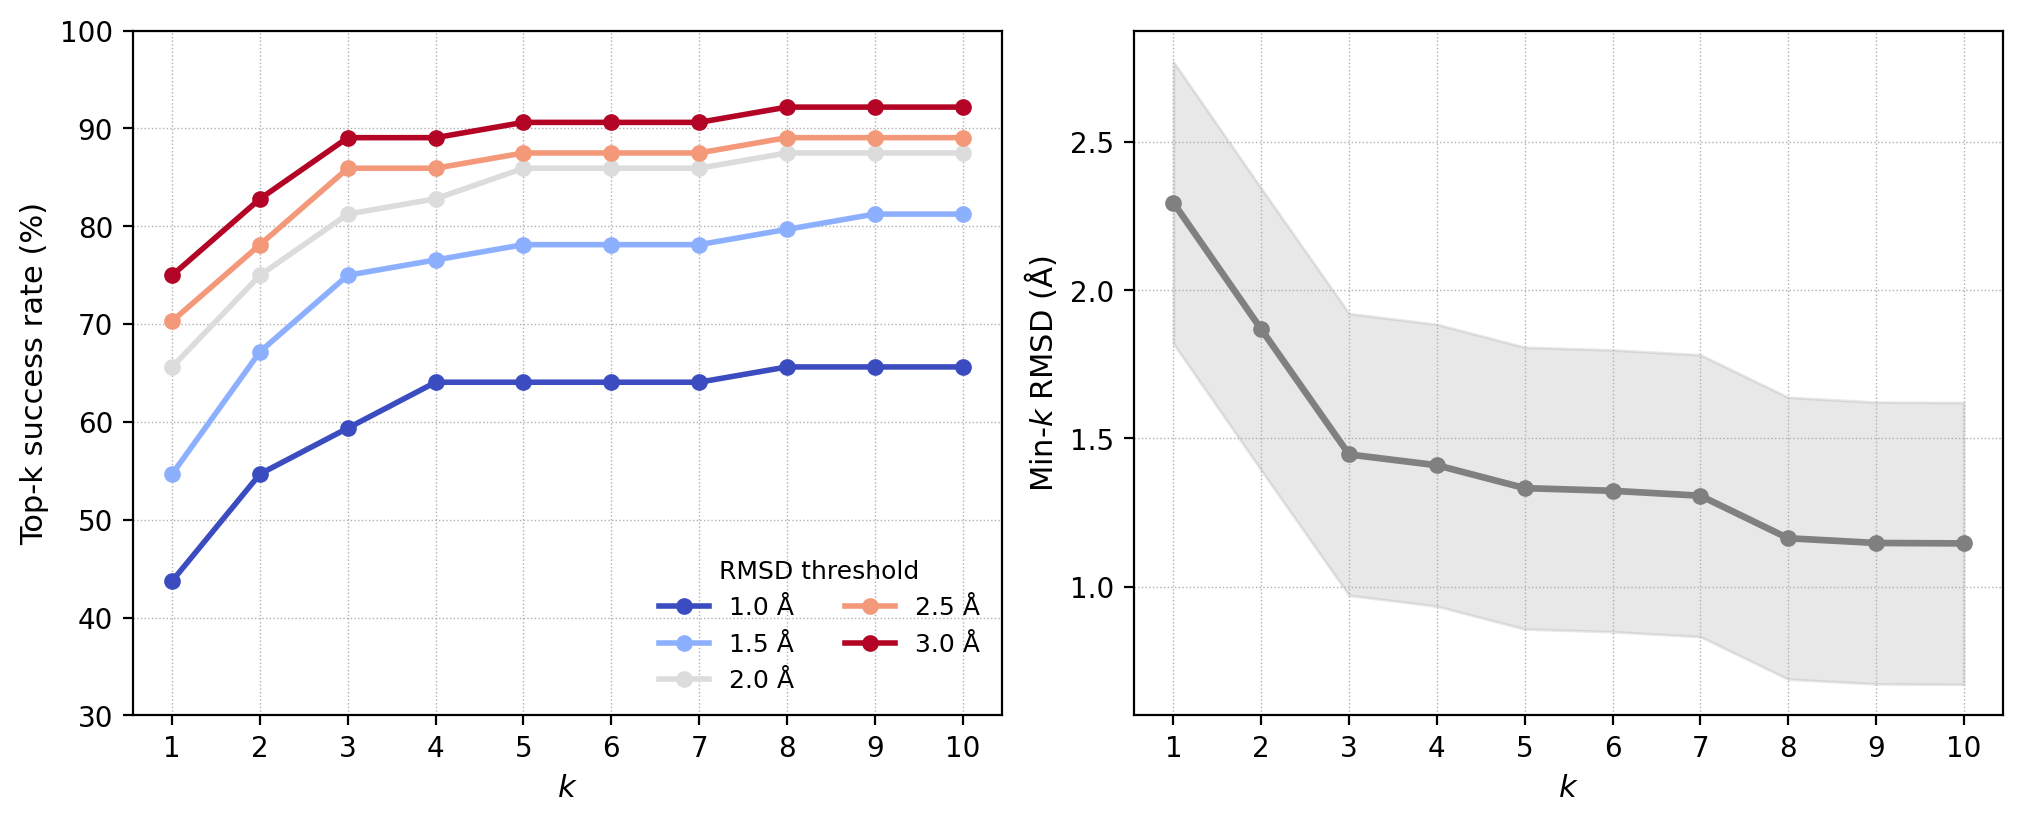

,Top-1.00Å,Top-1.50Å,Top-2.00Å,Top-2.50Å,Top-3.00Å
1,0.437500,0.546875,0.656250,0.703125,0.750000
2,0.546875,0.671875,0.750000,0.781250,0.828125
3,0.593750,0.750000,0.812500,0.859375,0.890625
4,0.640625,0.765625,0.828125,0.859375,0.890625
5,0.640625,0.781250,0.859375,0.875000,0.906250
6,0.640625,0.781250,0.859375,0.875000,0.906250
7,0.640625,0.781250,0.859375,0.875000,0.906250
8,0.656250,0.796875,0.875000,0.890625,0.921875
9,0.656250,0.812500,0.875000,0.890625,0.921875
10,0.656250,0.812500,0.875000,0.890625,0.921875


In [27]:
# PoseBusters + postprocessing + heuristics (requires: posebusters, pandas, spyrmsd)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Geometry import Point3D
import posebusters
import spyrmsd.molecule
import spyrmsd.rmsd
from tqdm import tqdm

from pytorch_lightning import seed_everything
from sigmadock.oracle import HPARAMS
from sigmadock.torch_utils.utils import re_batch_with_attrs

pbc = posebusters.PoseBusters(config="redock", max_workers=0)
num_graphs = all_outputs[0][0].num_graphs

all_rmsds = []
all_pb_checks = []
for idx in tqdm(range(num_graphs), desc="PoseBusters"):
    s_rmsds = []
    pb_checks = []
    for seed_idx in range(len(all_outputs)):
        sample_batch = all_outputs[seed_idx][0].to('cpu')
        sample = re_batch_with_attrs(sample_batch, ["pos_t", "pos_0"])[idx]
        mol_ref = sample.mol_info["original"]
        pred_coords = sample.pos_t * HPARAMS.general.dimensional_scale + sample.pocket_com
        frag_atom_idx = getattr(sample, "frag_atom_idx", getattr(sample, "frag_idx_map", None))
        is_lig = (frag_atom_idx != -1) & (sample.node_entity <= 1)
        pred_lig_coords = pred_coords[is_lig]
        mol = Chem.RWMol(mol_ref)
        mol.RemoveAllConformers()
        conf = Chem.Conformer(mol.GetNumAtoms())
        for i, (x, y, z) in enumerate(pred_lig_coords.tolist()):
            conf.SetAtomPosition(i, Point3D(x, y, z))
        _ = mol.AddConformer(conf, assignId=True)
        smol = spyrmsd.molecule.Molecule.from_rdkit(mol)
        rmol = spyrmsd.molecule.Molecule.from_rdkit(mol_ref)
        s_rmsd = spyrmsd.rmsd.rmsdwrapper(smol, rmol)[0]
        s_rmsds.append(s_rmsd)
        df = pbc.bust(mol, mol_ref, sample.mol_info["pocket"], full_report=False)
        pb_checks.append(df.copy())
    all_rmsds.append(s_rmsds)
    all_pb_checks.append(pd.concat(pb_checks))

# Postprocessing checks and heuristic ranking (as in extensions/sampling.ipynb)
postprocessing_checks = [
    "minimum_distance_to_protein", "tetrahedral_chirality", "internal_energy",
    "internal_steric_clash", "double_bond_flatness", "bond_lengths", "bond_angles",
]
seed_everything(1)  # Reproducible tie-breaking when scores are equal
stochasticity_max = 0.01
post_rmsds, scores_pb, post_valid_pb = [], [], []
for idx in range(len(all_pb_checks)):
    pb_mol = all_pb_checks[idx]
    per_seed_checks = pb_mol.get(postprocessing_checks)
    scores = np.array(per_seed_checks.mean(1).array)
    scores_pb.append(scores)
    post_is_valid = np.array((per_seed_checks.mean(1) == 1).array)
    post_valid_pb.append(pb_mol[post_is_valid])
    post_rmsds.append(np.array(all_rmsds)[idx][post_is_valid])

post_pb_checks, post_top_k, post_min_k = [], [], []
for idx in range(len(all_pb_checks)):
    score = np.array(scores_pb[idx]) + np.random.normal(0, stochasticity_max, size=scores_pb[idx].shape)
    descending = score.argsort()[-1::-1]
    sorted_rmsds = np.array([all_rmsds[idx][a] for a in descending])
    post_pb_checks.append(all_pb_checks[idx].iloc[descending])
    post_top_k.append([(sorted_rmsds[: i + 1] < 2).any() for i in range(len(sorted_rmsds))])
    post_min_k.append([sorted_rmsds[: i + 1].min() for i in range(len(sorted_rmsds))])

def heuristic_topk_and_mink(post_top_k, post_min_k, thresholds=(2.0,), ks=None):
    post_top_k_arr = np.array(post_top_k)
    post_min_k_arr = np.array(post_min_k)
    num_molecules, num_seeds = post_top_k_arr.shape
    ks = np.arange(1, num_seeds + 1) if ks is None else np.asarray([k for k in ks if 1 <= k <= num_seeds], dtype=int)
    thresholds = np.asarray(thresholds, dtype=float)
    mean_success = np.zeros((len(ks), len(thresholds)))
    std_success = np.zeros_like(mean_success)
    for ti, thr in enumerate(thresholds):
        for ki, k in enumerate(ks):
            mins = post_min_k_arr[:, k - 1]
            succ = mins < thr
            mean_success[ki, ti] = succ.mean()
            std_success[ki, ti] = succ.std(ddof=0)
    mean_min = post_min_k_arr[:, ks - 1].mean(axis=0)
    std_min = post_min_k_arr[:, ks - 1].std(axis=0, ddof=0)
    return {"thresholds": thresholds, "ks": ks, "mean_success": mean_success, "std_success": std_success,
            "mean_min": mean_min, "std_min": std_min, "num_molecules": num_molecules, "num_seeds": num_seeds}

def top_k_figure(stats, ax, show_bounds=True, cmap_name="turbo", ylim=None):
    ks, thresholds = stats["ks"], stats["thresholds"]
    mean_success, std_success = stats["mean_success"], stats["std_success"]
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i) for i in np.linspace(0, 1, len(thresholds))]
    for ti, t in enumerate(thresholds):
        m, s = mean_success[:, ti] * 100, std_success[:, ti] * 100
        ax.plot(ks, m, label=f"{t:.1f} Å", linewidth=2.0, marker="o", markersize=5, color=colors[ti])
        if show_bounds:
            ax.fill_between(ks, m - s, m + s, alpha=0.16, color=colors[ti])
    ax.set_xlabel("$k$", fontsize=11)
    ax.set_ylabel("Top-k success rate (%)", fontsize=11)
    ax.set_xticks(ks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle=":", linewidth=0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(title="RMSD threshold", fontsize=9, title_fontsize=9, frameon=False, ncol=2)

def delta_k_figure(stats, ax, show_bounds=True, ylim=None):
    ks, mean_min, std_min = stats["ks"], stats["mean_min"], stats["std_min"]
    ax.plot(ks, mean_min, linewidth=2.4, marker="o", markersize=5, color="gray")
    if show_bounds:
        iqr = np.percentile(mean_min, 75) - np.percentile(mean_min, 25)
        q1_ = np.percentile(mean_min, 25) - 1.5 * iqr
        q3_ = np.percentile(mean_min, 75) + 1.5 * iqr
        std_min = np.clip(std_min, a_min=None, a_max=(q3_ - q1_) / 2)
        min_b = np.maximum(mean_min - std_min, 0)
        ax.fill_between(ks, min_b, mean_min + std_min, alpha=0.18, color="gray")
    ax.set_xlabel("$k$", fontsize=11)
    ax.set_ylabel("Min-$k$ RMSD (Å)", fontsize=11)
    ax.set_xticks(ks)
    ax.grid(True, linestyle=":", linewidth=0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)

# With few seeds (e.g. 5) the top-k curve may look flat; extensions/sampling.ipynb uses more seeds for clearer effect.
heur_stats = heuristic_topk_and_mink(post_top_k, post_min_k, thresholds=[1, 1.5, 2, 2.5, 3])
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200, constrained_layout=True)
top_k_figure(heur_stats, axs[0], show_bounds=False, ylim=(30, 100), cmap_name="coolwarm")
delta_k_figure(heur_stats, axs[1], show_bounds=True)
plt.show()
heuristics_df = pd.DataFrame(
    heur_stats["mean_success"], index=heur_stats["ks"],
    columns=[f"Top-{t:.2f}Å" for t in heur_stats["thresholds"]],
)
heuristics_df